In [1]:
import json
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import awswrangler as wr

from sqlalchemy import create_engine

plt.style.use("ggplot")

RDS_REPLICA_HOST = "itam-flights-replica-780191826160.cy1scceyyo9b.us-east-1.rds.amazonaws.com"
SECRET_NAME = "itam/rds/flights/credentials"
REGION = "us-east-1"
ATHENA_OUTPUT = "s3://bronce-s3/athena-results/"

client = boto3.client("secretsmanager", region_name=REGION)
creds = json.loads(client.get_secret_value(SecretId=SECRET_NAME)["SecretString"])

engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{RDS_REPLICA_HOST}:{creds['port']}/{creds['dbname']}"
)

def run_pg(sql: str) -> pd.DataFrame:
    return pd.read_sql(sql, engine)

def run_athena(sql: str, database: str) -> pd.DataFrame:
    return wr.athena.read_sql_query(
        sql=sql,
        database=database,
        s3_output=ATHENA_OUTPUT,
        ctas_approach=False,
    )

print("Notebook listo")
print("Replica host:", RDS_REPLICA_HOST)
print("Database:", creds["dbname"])

Notebook listo
Replica host: itam-flights-replica-780191826160.cy1scceyyo9b.us-east-1.rds.amazonaws.com
Database: flights


In [1]:
!pip install statsforecast statsmodels scikit-learn -q

In [2]:
run_pg("SELECT COUNT(*) AS n FROM flights;")

,n
0,500000


In [3]:
##P1
sql_p1 = """
SELECT
    origin_airport,
    destination_airport,
    COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10;
"""

p1 = run_pg(sql_p1)
p1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


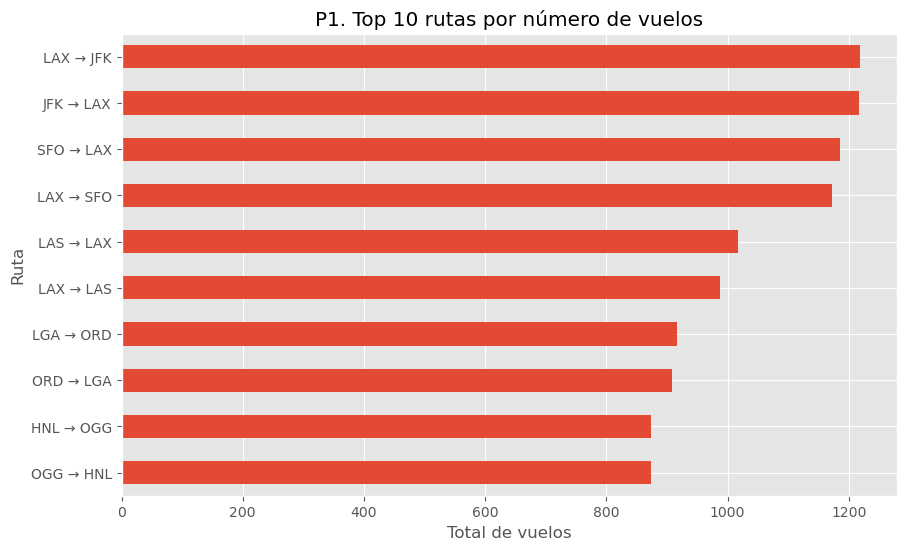

In [4]:
##Visualización de P1

p1["route"] = p1["origin_airport"] + " → " + p1["destination_airport"]

ax = p1.sort_values("total_flights").plot(
    kind="barh",
    x="route",
    y="total_flights",
    figsize=(10, 6),
    legend=False,
    title="P1. Top 10 rutas por número de vuelos"
)
ax.set_xlabel("Total de vuelos")
ax.set_ylabel("Ruta")
plt.show()

In [5]:
##Pregunta 2
sql_p2 = """
SELECT
    airline,
    COUNT(*) AS total_flights,
    SUM(cancelled) AS total_cancelled,
    ROUND((100.0 * SUM(cancelled) / COUNT(*))::numeric, 2) AS cancelled_pct
FROM flights
GROUP BY airline
ORDER BY cancelled_pct DESC, total_flights DESC
LIMIT 5;
"""

p2 = run_pg(sql_p2)
p2

,airline,total_flights,total_cancelled,cancelled_pct
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


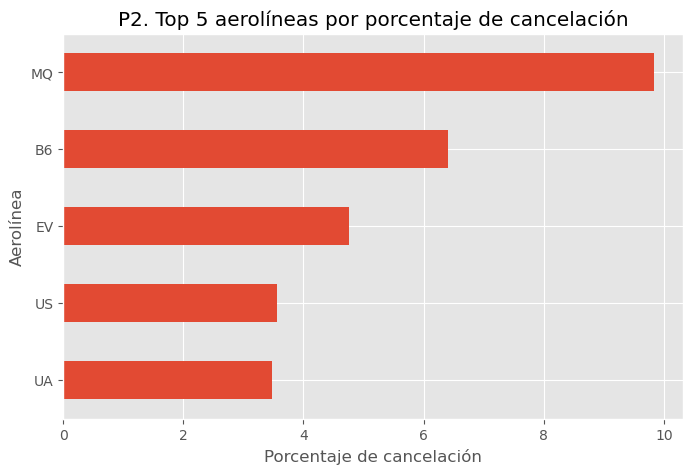

In [6]:
##Visualización P2
ax = p2.sort_values("cancelled_pct").plot(
    kind="barh",
    x="airline",
    y="cancelled_pct",
    figsize=(8, 5),
    legend=False,
    title="P2. Top 5 aerolíneas por porcentaje de cancelación"
)
ax.set_xlabel("Porcentaje de cancelación")
ax.set_ylabel("Aerolínea")
plt.show()

In [7]:
##Pregunta 3
sql_p3 = """
SELECT
    cancellation_reason,
    COUNT(*) AS total_cancelled
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total_cancelled DESC;
"""

p3 = run_pg(sql_p3)
p3

,cancellation_reason,total_cancelled
0,NaN,483176
1,B,10630
2,A,3230
3,C,2962
4,D,2


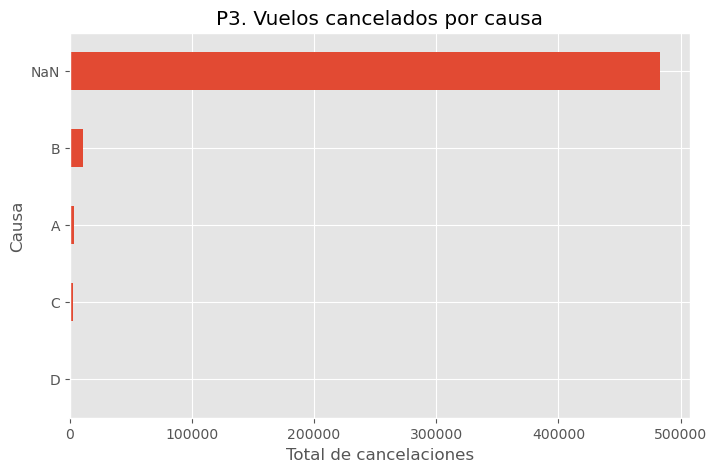

In [8]:
##Visualización P3

ax = p3.sort_values("total_cancelled").plot(
    kind="barh",
    x="cancellation_reason",
    y="total_cancelled",
    figsize=(8, 5),
    legend=False,
    title="P3. Vuelos cancelados por causa"
)
ax.set_xlabel("Total de cancelaciones")
ax.set_ylabel("Causa")
plt.show()

In [9]:
sql_p4 = """
SELECT
    month,
    ROUND(AVG(departure_delay)::numeric, 2) AS avg_departure_delay
FROM flights
WHERE cancelled = 0
  AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

p4 = run_pg(sql_p4)
p4

,month,avg_departure_delay
0,1,32.57
1,2,42.31


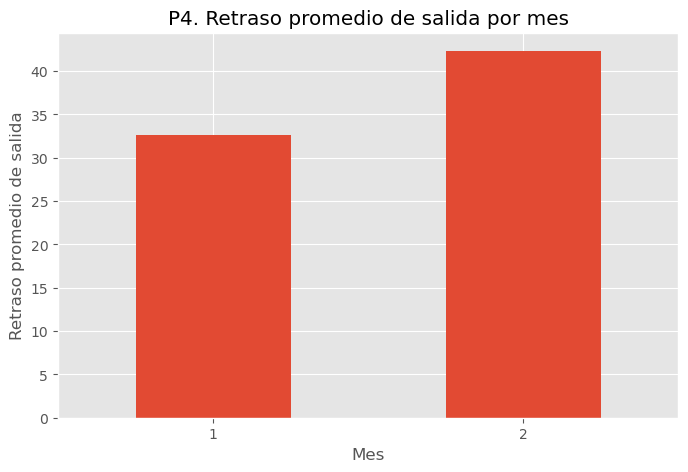

In [11]:
##Visualización P4
ax = p4.plot(
    kind="bar",
    x="month",
    y="avg_departure_delay",
    figsize=(8, 5),
    legend=False,
    title="P4. Retraso promedio de salida por mes"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Retraso promedio de salida")
plt.xticks(rotation=0)
plt.show()

In [12]:
##P5
sql_p5 = """
SELECT
    origin_airport,
    SUM(NULLIF(weather_delay, 'NaN'::double precision)) AS total_weather_delay_minutes
FROM flights
GROUP BY origin_airport
ORDER BY total_weather_delay_minutes DESC NULLS LAST
LIMIT 10;
"""

p5 = run_pg(sql_p5)
p5

,origin_airport,total_weather_delay_minutes
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


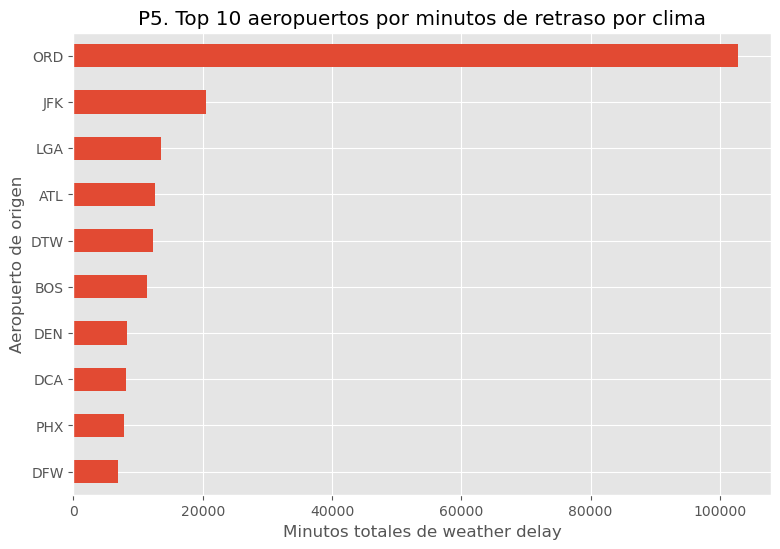

In [13]:
##Visualización P5
ax = p5.sort_values("total_weather_delay_minutes").plot(
    kind="barh",
    x="origin_airport",
    y="total_weather_delay_minutes",
    figsize=(9, 6),
    legend=False,
    title="P5. Top 10 aeropuertos por minutos de retraso por clima"
)
ax.set_xlabel("Minutos totales de weather delay")
ax.set_ylabel("Aeropuerto de origen")
plt.show()

In [14]:
##W1

sql_w1 = """
WITH ranked_flights AS (
    SELECT
        airline,
        origin_airport,
        destination_airport,
        year,
        month,
        day,
        arrival_delay,
        RANK() OVER (
            PARTITION BY airline
            ORDER BY arrival_delay DESC NULLS LAST
        ) AS delay_rank
    FROM flights
)
SELECT
    airline,
    origin_airport,
    destination_airport,
    year,
    month,
    day,
    arrival_delay
FROM ranked_flights
WHERE delay_rank = 1
ORDER BY airline;
"""

w1 = run_pg(sql_w1)
w1

,airline,origin_airport,destination_airport,year,month,day,arrival_delay
0,AA,PHX,DFW,2015,1,1,NaN
1,AA,SAT,DFW,2015,1,1,NaN
2,AA,DFW,ORD,2015,1,2,NaN
3,AA,ORD,MCO,2015,1,3,NaN
4,AA,TUS,DFW,2015,1,4,NaN
...,...,...,...,...,...,...,...
17943,WN,PVD,BWI,2015,1,28,NaN
17944,WN,PVD,TPA,2015,1,28,NaN
17945,WN,TPA,ALB,2015,1,27,NaN
17946,WN,EWR,MDW,2015,1,27,NaN


In [21]:
##W2
sql_w2 = """
WITH monthly_totals AS (
    SELECT
        month,
        SUM(total_flights) AS total_flights
    FROM flights_monthly
    GROUP BY month
),
monthly_with_lag AS (
    SELECT
        month,
        total_flights,
        LAG(total_flights) OVER (ORDER BY month) AS prev_month_flights
    FROM monthly_totals
)
SELECT
    month,
    total_flights,
    prev_month_flights,
    total_flights - prev_month_flights AS abs_change,
    ROUND(
        100.0 * (total_flights - prev_month_flights) / prev_month_flights,
        2
    ) AS pct_change
FROM monthly_with_lag
ORDER BY month
"""

w2 = run_athena(sql_w2, database="flights_silver")
w2

2026-04-14 00:12:31,390	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409956352 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.73gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-14 00:12:32,604	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,abs_change,pct_change
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.50
3,4,485151,504312,-19161,-3.80
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


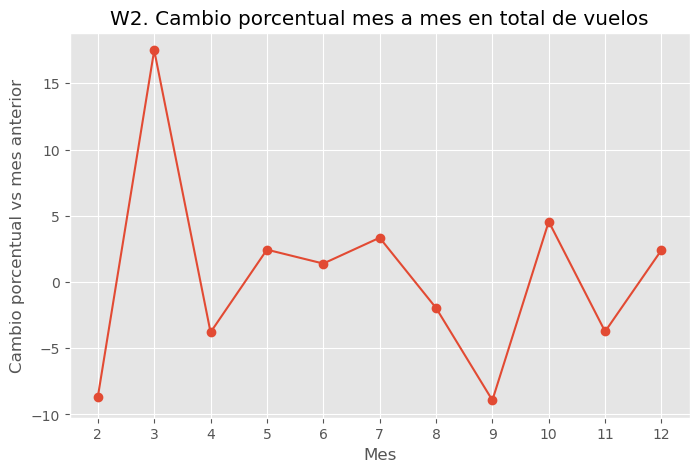

In [22]:
##

w2_plot = w2.dropna(subset=["pct_change"]).copy()

ax = w2_plot.plot(
    kind="line",
    x="month",
    y="pct_change",
    marker="o",
    figsize=(8, 5),
    legend=False,
    title="W2. Cambio porcentual mes a mes en total de vuelos"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Cambio porcentual vs mes anterior")
plt.xticks(w2_plot["month"])
plt.show()

In [23]:
###W3

sql_w3 = """
WITH ranked_lax AS (
    SELECT
        year,
        month,
        day,
        origin_airport,
        flight_number,
        airline,
        destination_airport,
        scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015
      AND month = 1
      AND day = 1
      AND origin_airport = 'LAX'
)
SELECT
    flight_number,
    airline,
    destination_airport,
    scheduled_departure,
    rn
FROM ranked_lax
WHERE rn <= 5
ORDER BY rn
"""

w3 = run_athena(sql_w3, database="flights_bronze")
w3

,flight_number,airline,destination_airport,scheduled_departure,rn
0,2336,AA,PBI,10,1
1,258,AA,MIA,20,2
2,2013,US,CLT,30,3
3,1434,DL,MSP,35,4
4,115,AA,MIA,105,5


In [24]:
###Visualización 

w3_style = (
    w3.style
      .set_caption("W3. Primeros 5 vuelos desde LAX el 2015-01-01 por horario programado")
)

w3_style

,flight_number,airline,destination_airport,scheduled_departure,rn
0,2336,AA,PBI,10,1
1,258,AA,MIA,20,2
2,2013,US,CLT,30,3
3,1434,DL,MSP,35,4
4,115,AA,MIA,105,5


In [ ]:
#Pregunta 8 

In [1]:
!pip install -q statsforecast statsmodels scikit-learn

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awswrangler as wr

import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [4]:
sql_reg = """
SELECT
    arrival_delay,
    departure_delay,
    distance,
    air_system_delay,
    airline_delay,
    weather_delay,
    late_aircraft_delay,
    security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
  AND arrival_delay IS NOT NULL
LIMIT 120000
"""

df_reg = wr.athena.read_sql_query(
    sql=sql_reg,
    database="flights_gold"
)

df_reg.head()

2026-04-14 17:59:18,377	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409964544 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.67gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-14 17:59:19,685	INFO worker.py:1852 -- Started a local Ray instance.


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,-18.0,-9.0,147,NaN,NaN,NaN,NaN,NaN
1,-25.0,-15.0,626,NaN,NaN,NaN,NaN,NaN
2,-31.0,-5.0,455,NaN,NaN,NaN,NaN,NaN
3,26.0,1.0,1846,26.0,0.0,0.0,0.0,0.0
4,-17.0,0.0,409,NaN,NaN,NaN,NaN,NaN


In [5]:
features = [
    "departure_delay",
    "distance",
    "air_system_delay",
    "airline_delay",
    "weather_delay",
    "late_aircraft_delay",
    "security_delay",
]

target = "arrival_delay"

cols_modelo = features + [target]

df_model = df_reg[cols_modelo].copy()

for col in cols_modelo:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.dropna().copy()

X = df_model[features].astype(float)
y = df_model[target].astype(float)

X = sm.add_constant(X)

print(df_model.shape)
print(X.dtypes)
print(y.dtype)

(22590, 8)
const                  float64
departure_delay        float64
distance               float64
air_system_delay       float64
airline_delay          float64
weather_delay          float64
late_aircraft_delay    float64
security_delay         float64
dtype: object
float64


In [6]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          arrival_delay   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.777e+33
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:00:01   Log-Likelihood:             6.4553e+05
No. Observations:               22590   AIC:                        -1.291e+06
Df Residuals:                   22582   BIC:                        -1.291e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 3.02e-14   1

In [7]:
y_hat = model.predict(X)
residuals = y - y_hat

r2 = model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_hat))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 1.0000
RMSE: 0.0000


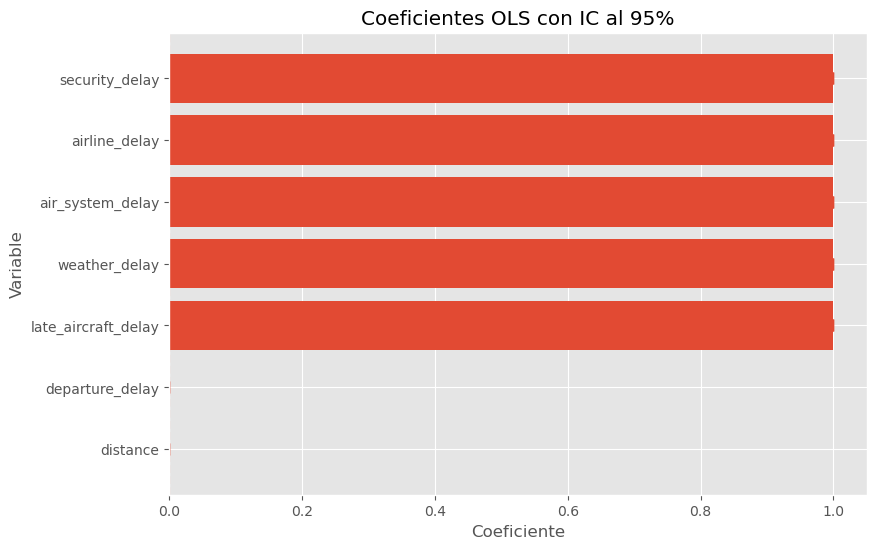

,feature,coef,ci_low,ci_high
2,distance,-2.558717e-17,-2.768494e-17,-2.348941e-17
1,departure_delay,1.214306e-15,1.146185e-15,1.282428e-15
6,late_aircraft_delay,1.000000e+00,1.000000e+00,1.000000e+00
5,weather_delay,1.000000e+00,1.000000e+00,1.000000e+00
3,air_system_delay,1.000000e+00,1.000000e+00,1.000000e+00
4,airline_delay,1.000000e+00,1.000000e+00,1.000000e+00
7,security_delay,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
conf_int = model.conf_int()
coef_df = pd.DataFrame({
    "feature": model.params.index,
    "coef": model.params.values,
    "ci_low": conf_int[0].values,
    "ci_high": conf_int[1].values
})

coef_df = coef_df[coef_df["feature"] != "const"].sort_values("coef")

plt.figure(figsize=(9, 6))
plt.barh(coef_df["feature"], coef_df["coef"])
plt.errorbar(
    x=coef_df["coef"],
    y=coef_df["feature"],
    xerr=[
        coef_df["coef"] - coef_df["ci_low"],
        coef_df["ci_high"] - coef_df["coef"]
    ],
    fmt="none",
    capsize=4
)
plt.axvline(0, linestyle="--")
plt.title("Coeficientes OLS con IC al 95%")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

coef_df

In [ ]:
#todas las que dicen delay tienen el mayor impacto (coeficientes cercanos a 1). pero, variables como distance o departure_delay tienen un impacto mucho menor.

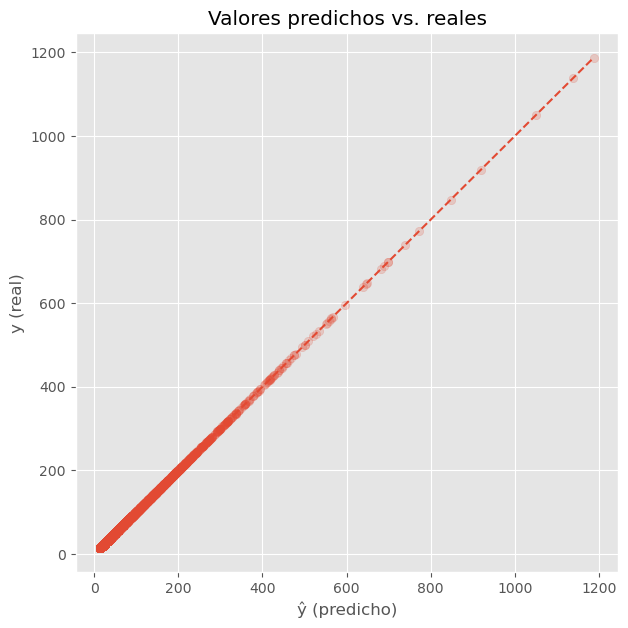

In [9]:
plot_df = pd.DataFrame({
    "y_real": y,
    "y_hat": y_hat
}).sample(min(10000, len(y)), random_state=42)

plt.figure(figsize=(7, 7))
plt.scatter(plot_df["y_hat"], plot_df["y_real"], alpha=0.2)
lims = [
    min(plot_df["y_real"].min(), plot_df["y_hat"].min()),
    max(plot_df["y_real"].max(), plot_df["y_hat"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.title("Valores predichos vs. reales")
plt.xlabel("ŷ (predicho)")
plt.ylabel("y (real)")
plt.show()

In [ ]:
# Se alinean bastante bien , aunque esto ocurre porque el modelo está usando variables que reconstruyen directamente el arrival_delay, no porque tenga una capacidad predictiva real.

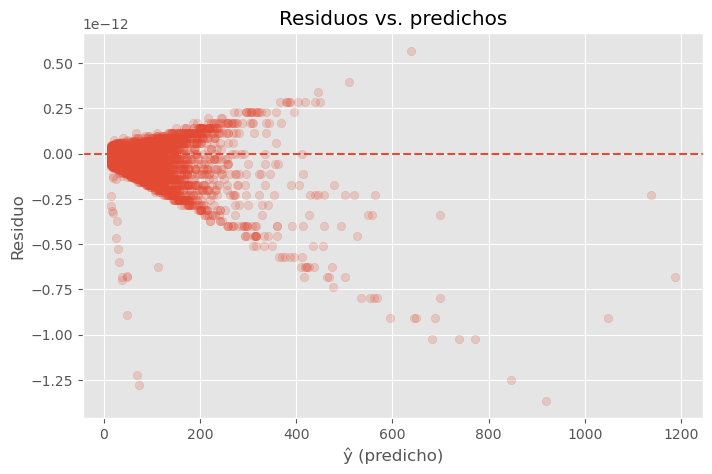

In [10]:
resid_plot_df = pd.DataFrame({
    "y_hat": y_hat,
    "residual": residuals
}).sample(min(10000, len(y_hat)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(resid_plot_df["y_hat"], resid_plot_df["residual"], alpha=0.2)
plt.axhline(0, linestyle="--")
plt.title("Residuos vs. predichos")
plt.xlabel("ŷ (predicho)")
plt.ylabel("Residuo")
plt.show()

In [ ]:
#Los residuos son prácticamente cero en todos los puntos

<Figure size 700x700 with 0 Axes>

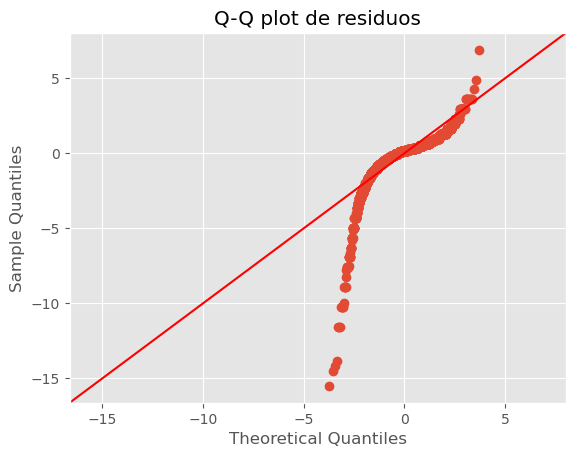

In [11]:
qq_resid = residuals.sample(min(10000, len(residuals)), random_state=42)

plt.figure(figsize=(7, 7))
qqplot(qq_resid, line="45", fit=True)
plt.title("Q-Q plot de residuos")
plt.show()

In [ ]:
#El Q-Q plot no permite evaluar adecuadamente la normalidad, ya que los residuos son casi nulos.

In [ ]:
#Se obtuvo un  valor de R² = 1.0000, y además presenta un RMSE de 0.0000 minutos. En los diagnósticos, los valores predichos coinciden casi exactamente con los reales y los residuos se concentran alrededor de cero, lo que indica un ajuste perfecto. Sin embargo, este resultado no implica que el modelo de eficaz  sino que varias variables explicativas son componentes directos del propio arrival_delay, por lo que existe una relación total.

In [12]:
sql_ts = """
SELECT
    month,
    SUM(total_flights) AS total_flights
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month
"""

df_ts_raw = wr.athena.read_sql_query(
    sql=sql_ts,
    database="flights_silver"
)

df_ts_raw

,month,total_flights
0,1,469968
1,2,429191
2,3,504312
3,4,485151
4,5,496993
5,6,503897
6,7,520718
7,8,510536
8,9,464946
9,10,486165


In [13]:
df_ts = df_ts_raw.copy()

df_ts["month"] = pd.to_numeric(df_ts["month"], errors="coerce")
df_ts["total_flights"] = pd.to_numeric(df_ts["total_flights"], errors="coerce")

df_ts = df_ts.dropna().copy()

df_ts["ds"] = pd.to_datetime({
    "year": 2015,
    "month": df_ts["month"].astype(int),
    "day": 1
})
df_ts["unique_id"] = "flights_2015"
df_ts["y"] = df_ts["total_flights"].astype(float)

df_ts = df_ts[["unique_id", "ds", "y"]].sort_values("ds").reset_index(drop=True)
df_ts

,unique_id,ds,y
0,flights_2015,2015-01-01,469968.0
1,flights_2015,2015-02-01,429191.0
2,flights_2015,2015-03-01,504312.0
3,flights_2015,2015-04-01,485151.0
4,flights_2015,2015-05-01,496993.0
5,flights_2015,2015-06-01,503897.0
6,flights_2015,2015-07-01,520718.0
7,flights_2015,2015-08-01,510536.0
8,flights_2015,2015-09-01,464946.0
9,flights_2015,2015-10-01,486165.0


In [14]:
train = df_ts[df_ts["ds"] <= "2015-09-01"].copy()
test = df_ts[(df_ts["ds"] >= "2015-10-01") & (df_ts["ds"] <= "2015-12-01")].copy()

print("Train")
display(train)

print("Test")
display(test)

Train


,unique_id,ds,y
0,flights_2015,2015-01-01,469968.0
1,flights_2015,2015-02-01,429191.0
2,flights_2015,2015-03-01,504312.0
3,flights_2015,2015-04-01,485151.0
4,flights_2015,2015-05-01,496993.0
5,flights_2015,2015-06-01,503897.0
6,flights_2015,2015-07-01,520718.0
7,flights_2015,2015-08-01,510536.0
8,flights_2015,2015-09-01,464946.0


Test


,unique_id,ds,y
9,flights_2015,2015-10-01,486165.0
10,flights_2015,2015-11-01,467972.0
11,flights_2015,2015-12-01,479230.0


In [15]:
models = [
    AutoETS(season_length=12, model="ZZZ"),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=1
)

sf.fit(train)
forecast_9 = sf.predict(h=9, level=[90]).reset_index()

forecast_9

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,flights_2015,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,flights_2015,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,flights_2015,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500
3,3,flights_2015,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,flights_2015,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,flights_2015,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,flights_2015,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,flights_2015,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,flights_2015,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


In [16]:
forecast_test = forecast_9.iloc[:3].copy()
forecast_future = forecast_9.iloc[3:].copy()

print("Pronóstico test")
display(forecast_test)

print("Pronóstico futuro")
display(forecast_future)

Pronóstico test


,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,flights_2015,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,flights_2015,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,flights_2015,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500


Pronóstico futuro


,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
3,3,flights_2015,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,flights_2015,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,flights_2015,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,flights_2015,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,flights_2015,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,flights_2015,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


In [17]:
test_eval = test.merge(
    forecast_test,
    on=["unique_id", "ds"],
    how="left"
)

mae_results = pd.DataFrame({
    "model": ["AutoETS", "AutoARIMA", "AutoTheta"],
    "MAE": [
        mean_absolute_error(test_eval["y"], test_eval["AutoETS"]),
        mean_absolute_error(test_eval["y"], test_eval["AutoARIMA"]),
        mean_absolute_error(test_eval["y"], test_eval["AutoTheta"]),
    ]
}).sort_values("MAE")

mae_results

,model,MAE
1,AutoARIMA,9512.333333
0,AutoETS,9530.908434
2,AutoTheta,18735.261068


In [ ]:
#El modelo con mejor desempeño fue AutoARIMA, ya que obtuvo el menor MAE

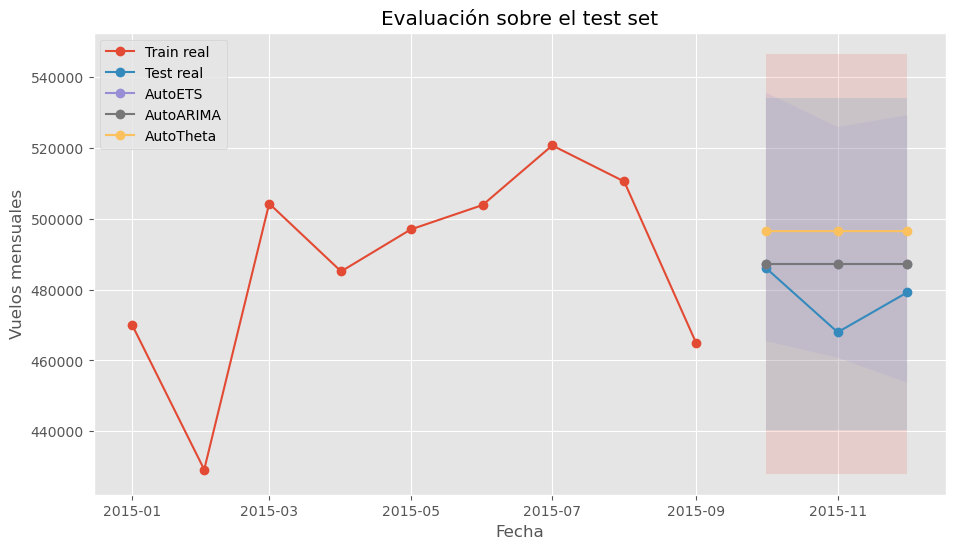

In [18]:
plt.figure(figsize=(11, 6))

plt.plot(train["ds"], train["y"], marker="o", label="Train real")
plt.plot(test["ds"], test["y"], marker="o", label="Test real")

for model_name in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(
        forecast_test["ds"],
        forecast_test[model_name],
        marker="o",
        label=f"{model_name}"
    )

    lo_col = f"{model_name}-lo-90"
    hi_col = f"{model_name}-hi-90"

    if lo_col in forecast_test.columns and hi_col in forecast_test.columns:
        plt.fill_between(
            forecast_test["ds"],
            forecast_test[lo_col],
            forecast_test[hi_col],
            alpha=0.15
        )

plt.title("Evaluación sobre el test set")
plt.xlabel("Fecha")
plt.ylabel("Vuelos mensuales")
plt.legend()
plt.show()

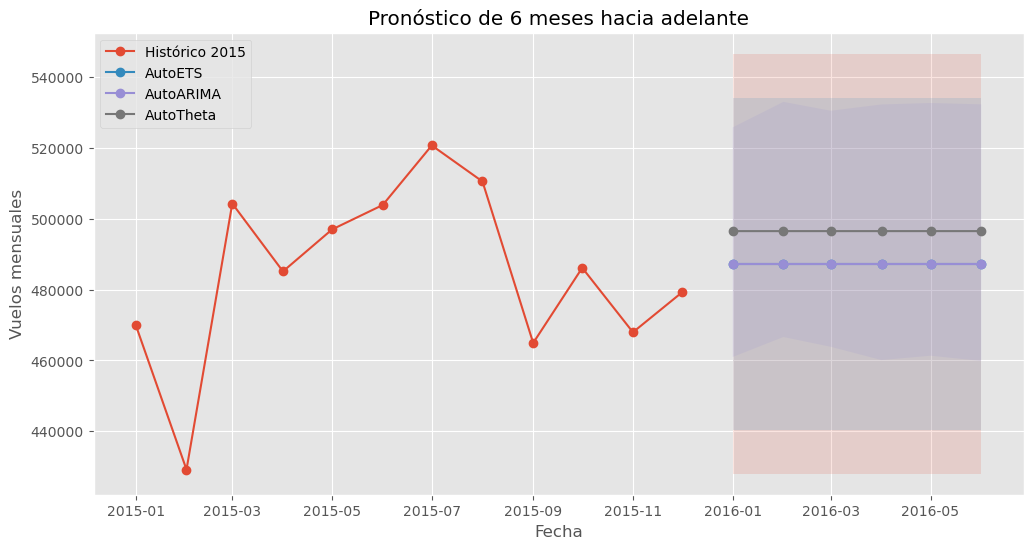

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts["ds"], df_ts["y"], marker="o", label="Histórico 2015")

for model_name in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(
        forecast_future["ds"],
        forecast_future[model_name],
        marker="o",
        label=f"{model_name}"
    )

    lo_col = f"{model_name}-lo-90"
    hi_col = f"{model_name}-hi-90"

    if lo_col in forecast_future.columns and hi_col in forecast_future.columns:
        plt.fill_between(
            forecast_future["ds"],
            forecast_future[lo_col],
            forecast_future[hi_col],
            alpha=0.15
        )

plt.title("Pronóstico de 6 meses hacia adelante")
plt.xlabel("Fecha")
plt.ylabel("Vuelos mensuales")
plt.legend()
plt.show()

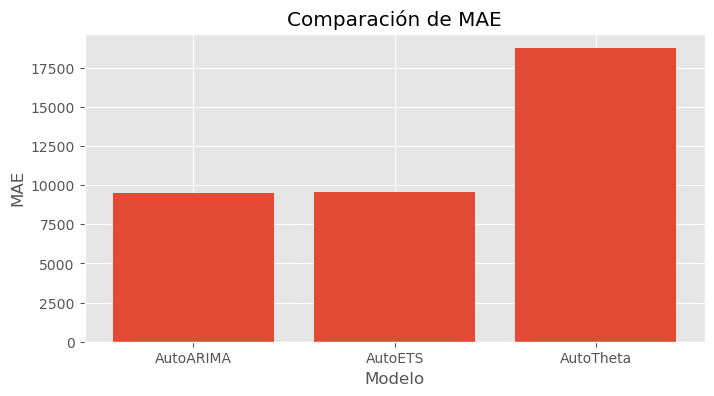

,model,MAE
1,AutoARIMA,9512.333333
0,AutoETS,9530.908434
2,AutoTheta,18735.261068


In [20]:
plt.figure(figsize=(8, 4))
plt.bar(mae_results["model"], mae_results["MAE"])
plt.title("Comparación de MAE")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.show()

mae_results

In [21]:
print(sf.fitted_)

[[AutoETS AutoARIMA AutoTheta]]


In [ ]:
#El mejor modelo fue AutoARIMA, con el menor MAE. Sin embargo, la diferencia con AutoETS es pequeña. Los intervalos de confianza al 90% deben interpretarse con cierta reserva, ya que el conjunto de datos es pequeño.